# [To be updated] Some figures that we should have in Supp Figures.

To add:

Dual occluders
- All averaged trajectories per mouse ✅
- Initial start per mouse and averaged ✅
- Tortuosity and duration ✅
- p values in trial progression plots for each line (in Fig 2-3)
- distance to choice ✅
- heading direction ✅
- head-body angle ✅
- vel x and y ✅
- prediction with only one params vs all the params in the logistic regression ?

Multiple occluders: all that was not shown
- All averaged trajectories ✅
- trial left choice proba ✅

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
%run env.py
%run run.py connect

2025-02-12 13:41:56,005::INFO::settings.py::Setting loglevel to INFO
2025-02-12 13:41:56,006::INFO::settings.py::Setting stores to {}
2025-02-12 13:41:56,007::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-12 13:41:56,012::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-12 13:41:56,012::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-12 13:41:56,016::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-02-12 13:41:56,017::INFO::settings.py::Setting database.user to celia
2025-02-12 13:41:56,018::INFO::settings.py::Setting database.password to celia
2025-02-12 13:41:56,082::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-02-12 13:41:56,093::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-02-12 13:41:56,482::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,482::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,501::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,501::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,532::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,532::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,564::INFO::table.py::could not log event in table ~log
2025-02-12 13:41:56,564::INFO::table.py::could not log event in table ~log


In [5]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

# Training [tbd]

# Dual occluders

In [6]:
big_df = pd.read_pickle("big_df_contrast_dual.pkl")
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [7]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped =  analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

mean_mouse = j_shaped.groupby(
    ["mouse_name", "dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

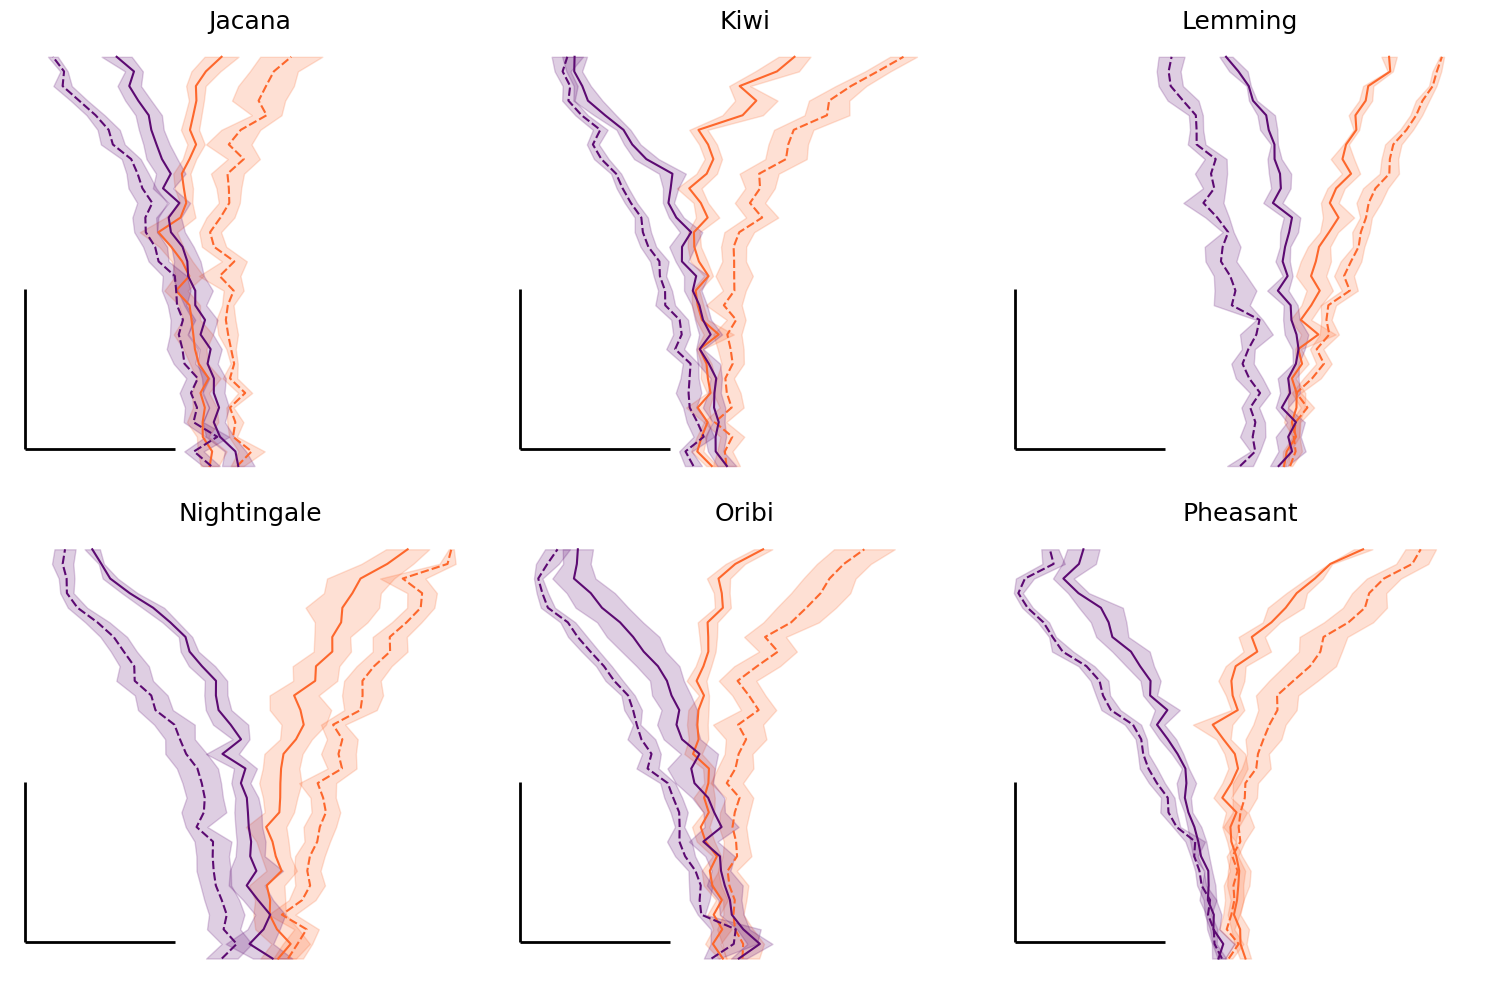

In [8]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax=ax.flatten()

for j, mouse in enumerate(mean_mouse.mouse_name.unique()):
    plotting.lineplot_flip_axis(
        data=mean_mouse[mean_mouse.mouse_name == mouse],
        x="bin_centers",
        y="x",
        hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
        palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else "viridis",
        style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "choice",
        errorbar="se",
        ax=ax[j],
    )
    ax[j].set_ylabel("y position")
    ax[j].set_xlabel("x position")
    ax[j].set_xlim(-16,16)
    ax[j].vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
    ax[j].hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
    ax[j].axis('off')
    ax[j].set_title(mouse)
    ax[j].legend([],[], frameon=False)
    
plt.tight_layout()
plt.savefig(save_fig_path + "mean_trajectory_per_mouse.svg", transparent =True)

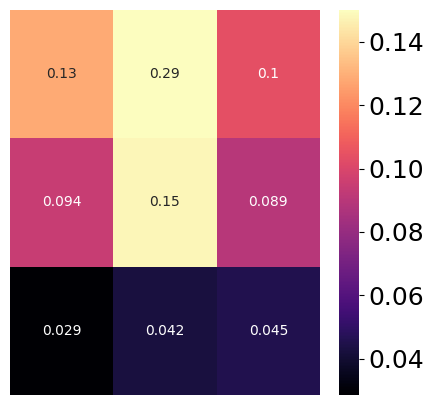

In [9]:
# Averaged initial starting position
fig, ax = plt.subplots(8, 6, figsize=(25, 25))
ax = ax.flatten()

df_init = big_df

hists = []
for i, session in enumerate(df_init.dataset.unique()):
    hist = plotting.plot_init_position_histogram(
        df_init[df_init.dataset == session],
        box_df,
        ax=ax[i],
        bins=3,
        cmap="magma",
        vmax=40,
        is_density=False,
    )

    number_trials = df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
    hist = hist / number_trials
    hists.append(hist)

    ax[i].set_title(f"{session}")
#plt.close()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(
    np.flip(np.mean(hists, axis=0), axis=1).T,
    cmap="magma",
    annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
    vmax=0.15,
)

ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [10]:
# Averaged initial starting position
df_init = big_df

fig_global, ax_global = plt.subplots(2, 3, figsize=(15, 20))
ax_global = ax_global.flatten()

for j, mouse in enumerate(df_init.mouse_name.unique()):
    fig, ax = plt.subplots(8, 6, figsize=(25, 25))
    ax = ax.flatten()
    hists = []
    for i, session in enumerate(df_init.dataset.unique()):
        hist = plotting.plot_init_position_histogram(
            df_init[df_init.dataset == session],
            box_df,
            ax=ax[i],
            bins=3,
            cmap="magma",
            vmax=40,
            is_density=False,
        )

        number_trials = df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
        hist = hist / number_trials
        hists.append(hist)

        #ax[i].set_title(f"{session}")
    plt.close(fig)

    sns.heatmap(
        np.flip(np.mean(hists, axis=0), axis=1).T,
        cmap="magma",
        annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
        vmax=0.15,
        ax=ax_global[j]
    )

    ax_global[j].set_xticks([])
    ax_global[j].set_yticks([])
    ax_global[j].set_title(f"{mouse}")
plt.show()

Text(0.5, 12.52222222222222, 'Trial duration (s)')

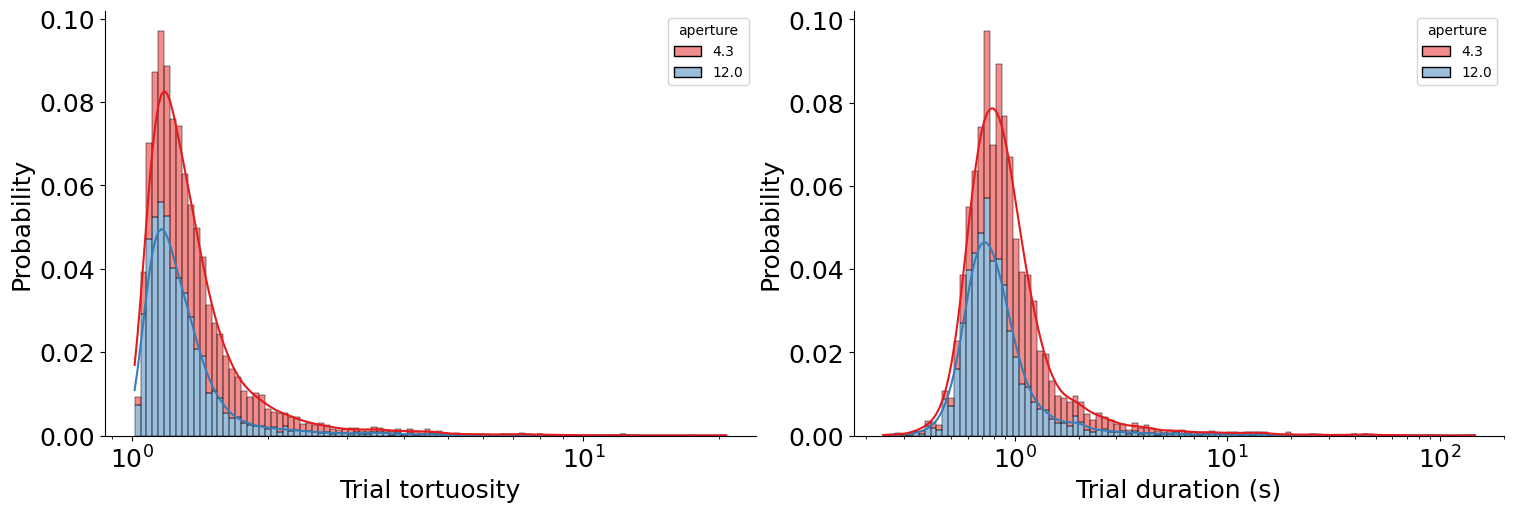

In [11]:
# Tortuosity and duration
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = plotting.plot_tortuosity_duration_distribution(big_df, ax=ax, log_scale=True)
fig.tight_layout(pad=0.2)
ax[0].set_xlabel("Trial tortuosity")
ax[1].set_xlabel("Trial duration (s)")

In [12]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

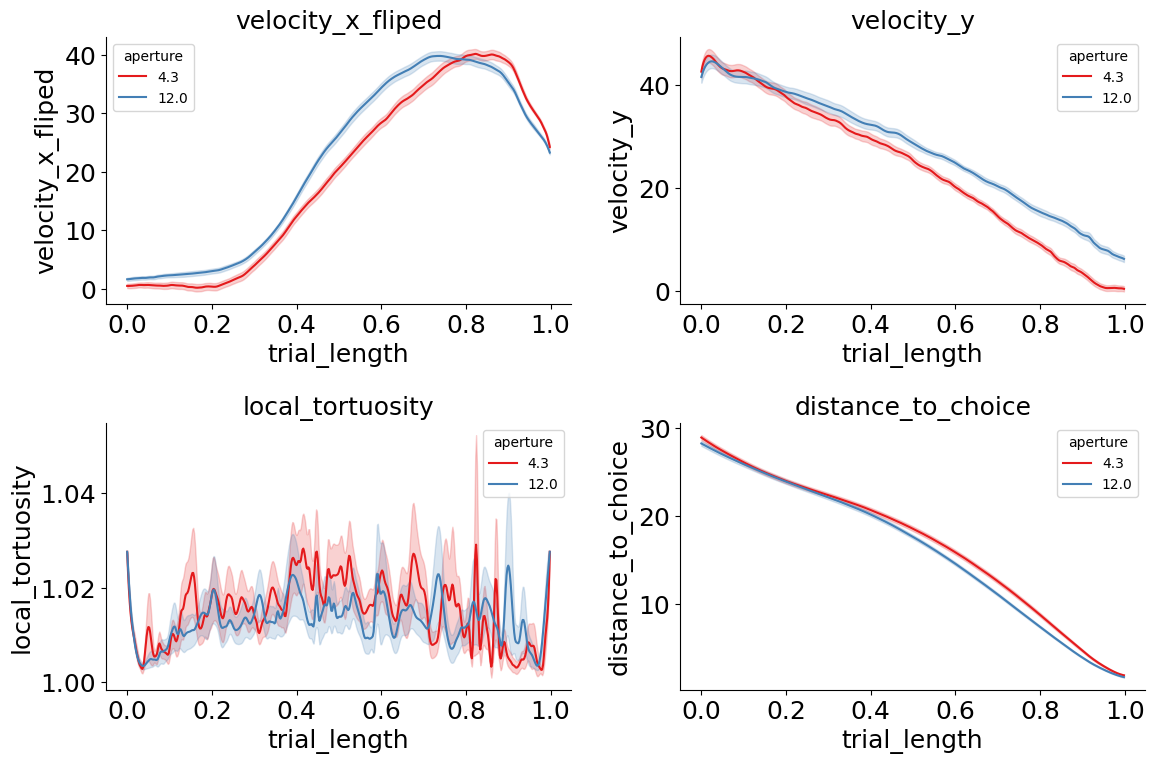

In [18]:
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for i, label in enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else "viridis"
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
plt.tight_layout(pad=2)

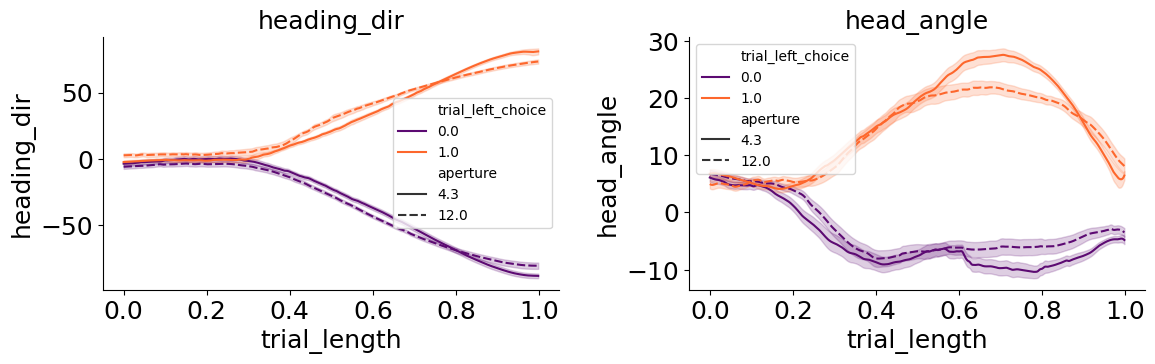

In [21]:
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

for i, label in enumerate(["heading_dir", "head_angle"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
    
        
plt.tight_layout(pad=2)

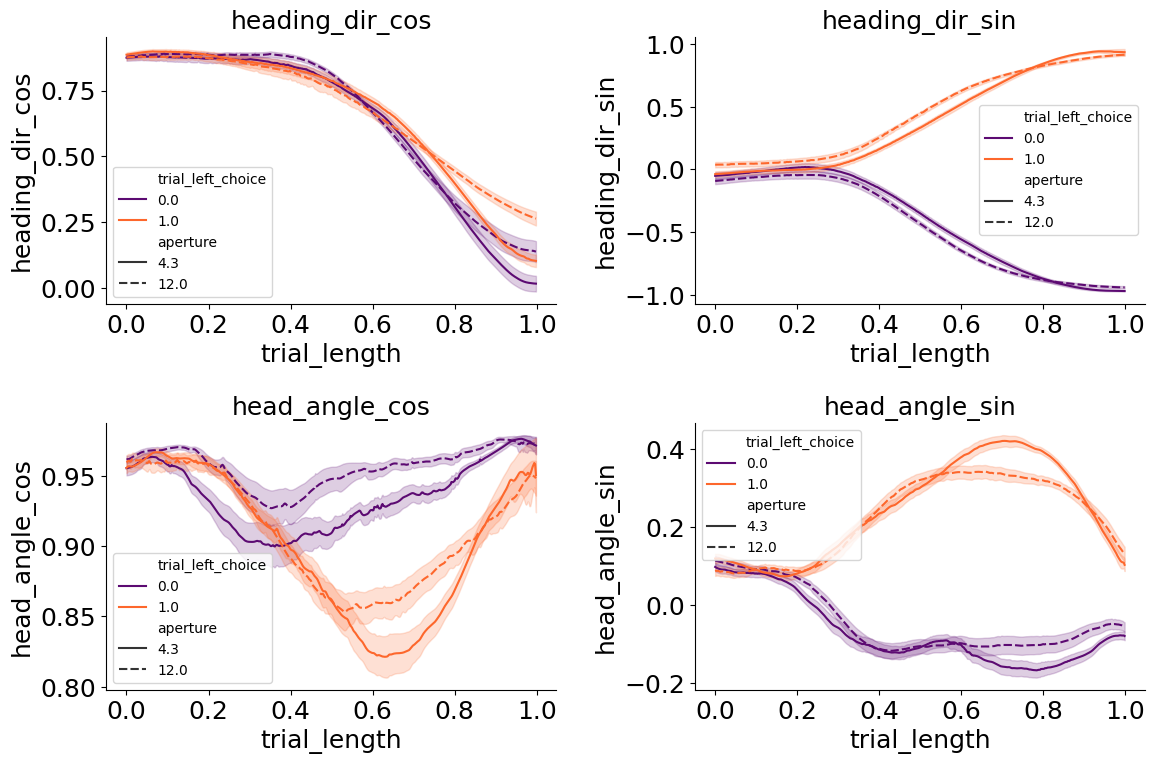

In [22]:
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for i, label in enumerate(["heading_dir_cos",  "heading_dir_sin", "head_angle_cos", "head_angle_sin"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
    
        
plt.tight_layout(pad=2)

## Multi occluders

In [23]:
big_df = pd.read_pickle("big_df_contrast_multi.pkl")
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

2025-02-12 14:58:00,525::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:58:00,525::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:58:00,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:58:00,535::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 14:58:00,616::INFO::category.py::Using categorical un

              mean       sem
aperture                    
12.0      0.519473  0.013185
3.0       0.496039  0.025693
4.2       0.491506  0.018621
6.0       0.484860  0.012938
8.48      0.504526  0.017802


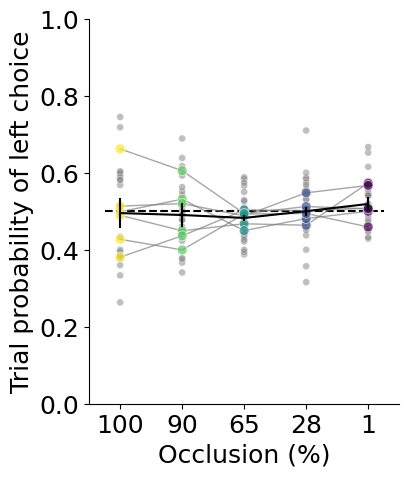

In [103]:
# Trial probability of left choice
fig,ax = plt.subplots(1,1, figsize = (4,5))
plotting.plot_rate(
    df=big_df,
    label_x="trial_left_choice",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True
)

ax.set_xlim(-0.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
ax.set_xlabel("Occlusion (%)")
ax.set_ylim(0, 1)
plt.legend([],[], frameon=False)
ax.set_ylabel("Trial probability of left choice")
ax.hlines(0.5, xmin=-0.25, xmax=len(big_df.aperture.unique())-0.75, linestyles="dashed", colors="k")

In [24]:
# Filter the data - no iti and only J_shaped trials
big_df = big_df [big_df.iti == 0.0].copy()
j_shaped =  analysis.get_jshaped_trials(big_df)
j_shaped = utils.create_bins(data=j_shaped.copy(), spatial_ybins=[6.75, 20, 30], label="y")

mean_mouse = j_shaped.groupby(
    ["mouse_name", "dataset", "trial_left_choice", "aperture", "bin_centers"], as_index=False
).mean(numeric_only =True).copy()

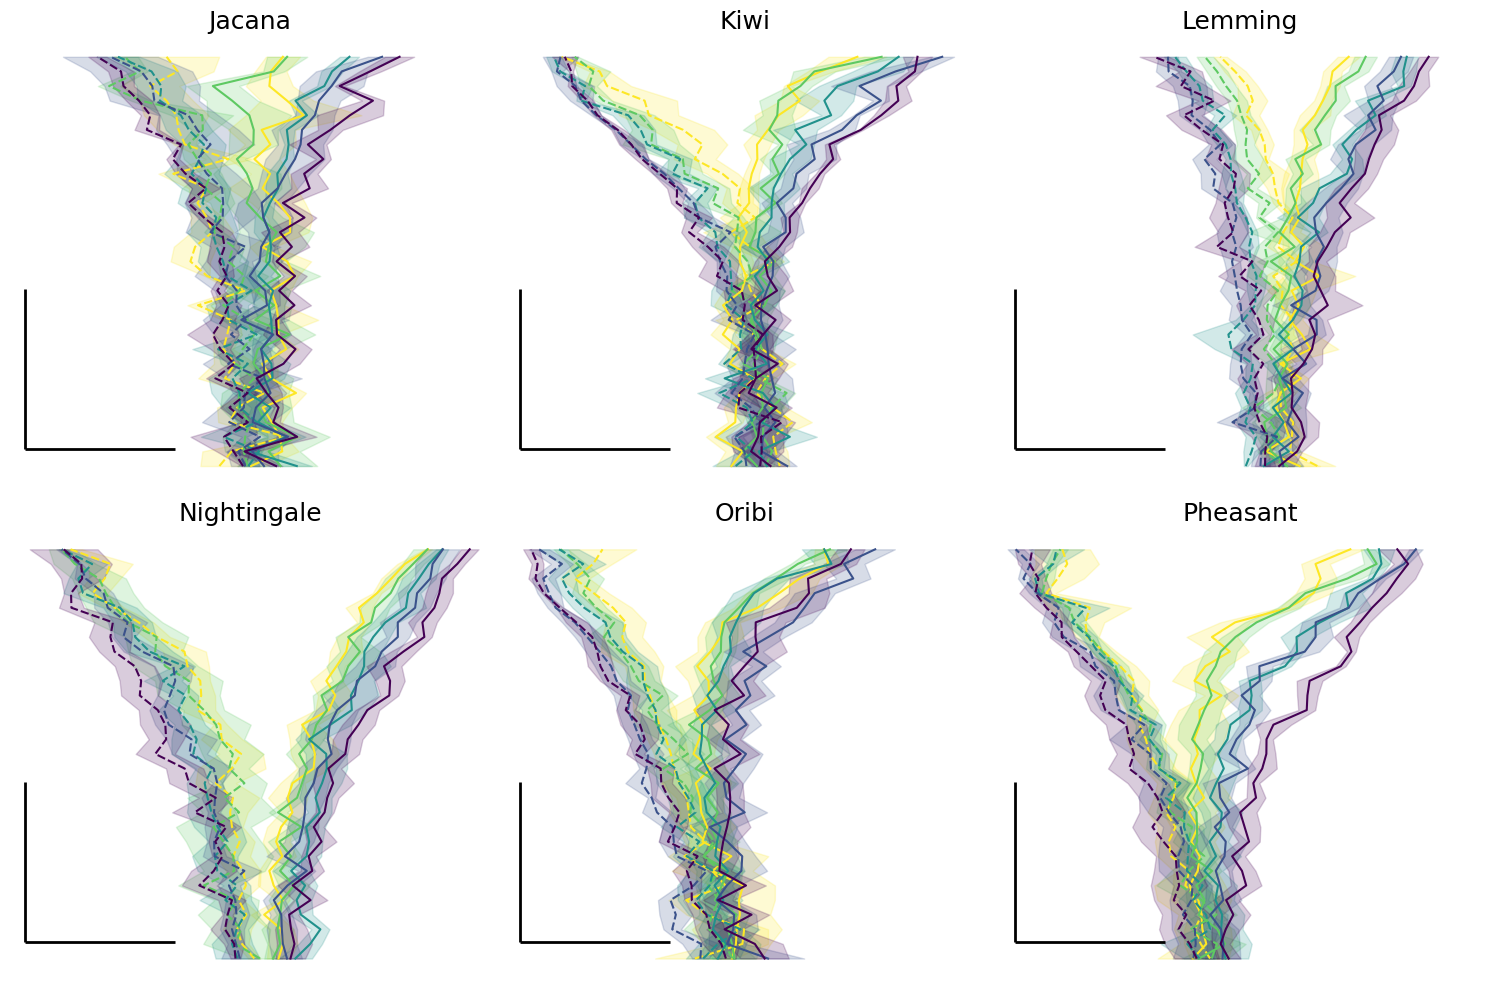

In [30]:
fig, ax = plt.subplots(2, 3, figsize=(15, 10))
ax=ax.flatten()

for j, mouse in enumerate(mean_mouse.mouse_name.unique()):
    plotting.lineplot_flip_axis(
        data=mean_mouse[mean_mouse.mouse_name == mouse],
        x="bin_centers",
        y="x",
        hue="trial_left_choice" if len(mean_mouse.aperture.unique()) == 2 else "aperture",
        palette=plotting.colors_choice[::-1] if len(mean_mouse.aperture.unique()) == 2 else plotting.colors_multi_aperture,
        style="aperture" if len(mean_mouse.aperture.unique()) == 2 else "trial_left_choice",
        errorbar="se",
        ax=ax[j],
    )
    ax[j].set_ylabel("y position")
    ax[j].set_xlabel("x position")
    ax[j].set_xlim(-16,16)
    ax[j].vlines(x=-15, ymin=7.5, ymax=12.5, color="black", linewidth=2)
    ax[j].hlines(y=7.5, xmin=-15, xmax=-5, color="black", linewidth=2)
    ax[j].axis('off')
    ax[j].set_title(mouse)
    ax[j].legend([],[], frameon=False)
    
plt.tight_layout()
plt.savefig(save_fig_path + "mean_trajectory_per_mouse.svg", transparent =True)

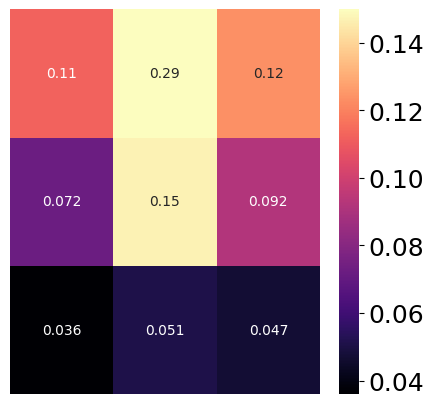

In [28]:
# Averaged initial starting position
fig, ax = plt.subplots(8, 6, figsize=(25, 25))
ax = ax.flatten()

df_init = big_df

hists = []
for i, session in enumerate(df_init.dataset.unique()):
    hist = plotting.plot_init_position_histogram(
        df_init[df_init.dataset == session],
        box_df,
        ax=ax[i],
        bins=3,
        cmap="magma",
        vmax=40,
        is_density=False,
    )

    number_trials = df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
    hist = hist / number_trials
    hists.append(hist)

    ax[i].set_title(f"{session}")
#plt.close()

fig, ax = plt.subplots(1, 1, figsize=(5, 5))

sns.heatmap(
    np.flip(np.mean(hists, axis=0), axis=1).T,
    cmap="magma",
    annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
    vmax=0.15,
)

ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [38]:
# Averaged initial starting position
df_init = big_df

fig_global, ax_global = plt.subplots(2, 3, figsize=(15, 10))
ax_global = ax_global.flatten()

for j, mouse in enumerate(df_init.mouse_name.unique()):
    fig, ax = plt.subplots(8, 6, figsize=(25, 25))
    ax = ax.flatten()
    hists = []
    for i, session in enumerate(df_init.dataset.unique()):
        hist = plotting.plot_init_position_histogram(
            df_init[df_init.dataset == session],
            box_df,
            ax=ax[i],
            bins=3,
            cmap="magma",
            vmax=40,
            is_density=False,
        )

        number_trials = df_init[df_init.dataset == session].groupby(["trial"]).x.first().count()
        hist = hist / number_trials
        hists.append(hist)

        #ax[i].set_title(f"{session}")
    plt.close(fig)

    sns.heatmap(
        np.flip(np.mean(hists, axis=0), axis=1).T,
        cmap="magma",
        annot=(np.flip(np.mean(hists, axis=0), axis=1).T),
        vmax=0.15,
        ax=ax_global[j]
    )

    ax_global[j].set_xticks([])
    ax_global[j].set_yticks([])
    ax_global[j].set_title(f"{mouse}")
plt.show()

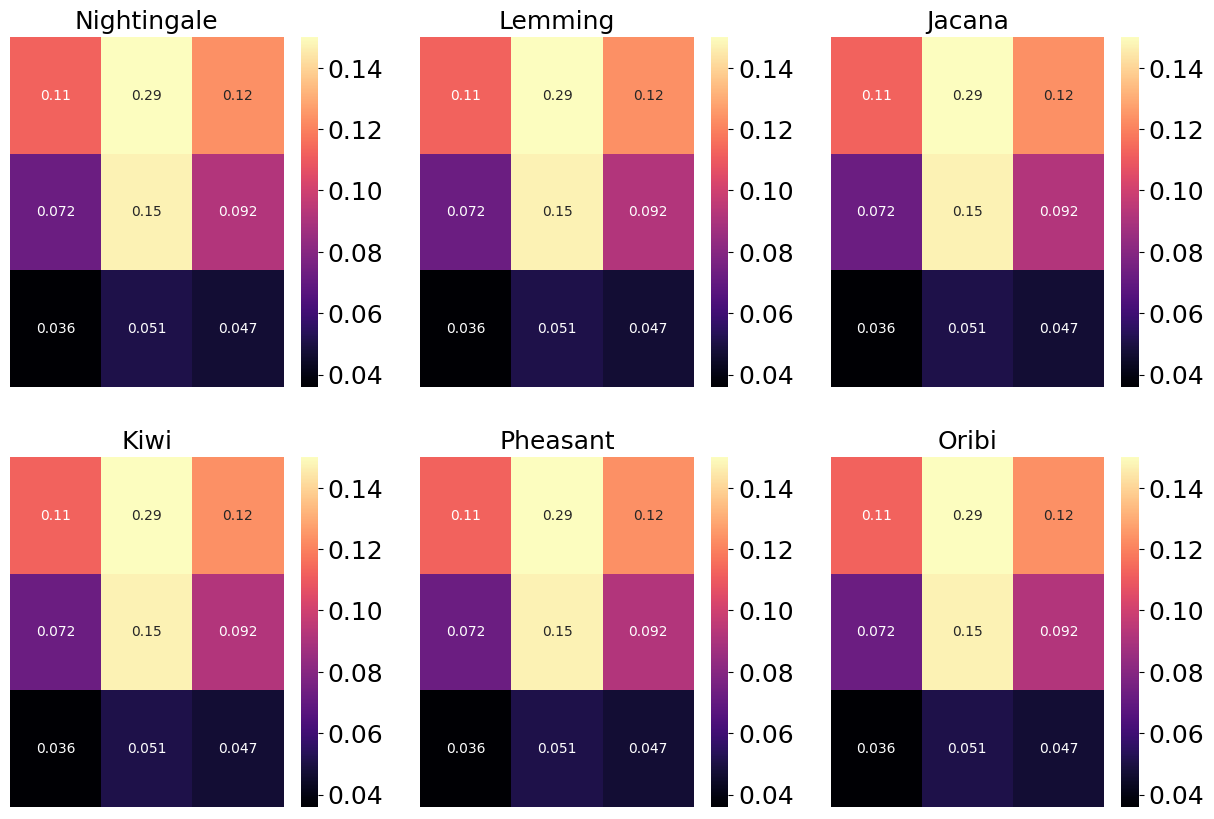

In [39]:
fig_global

Text(0.5, 12.52222222222222, 'Trial duration (s)')

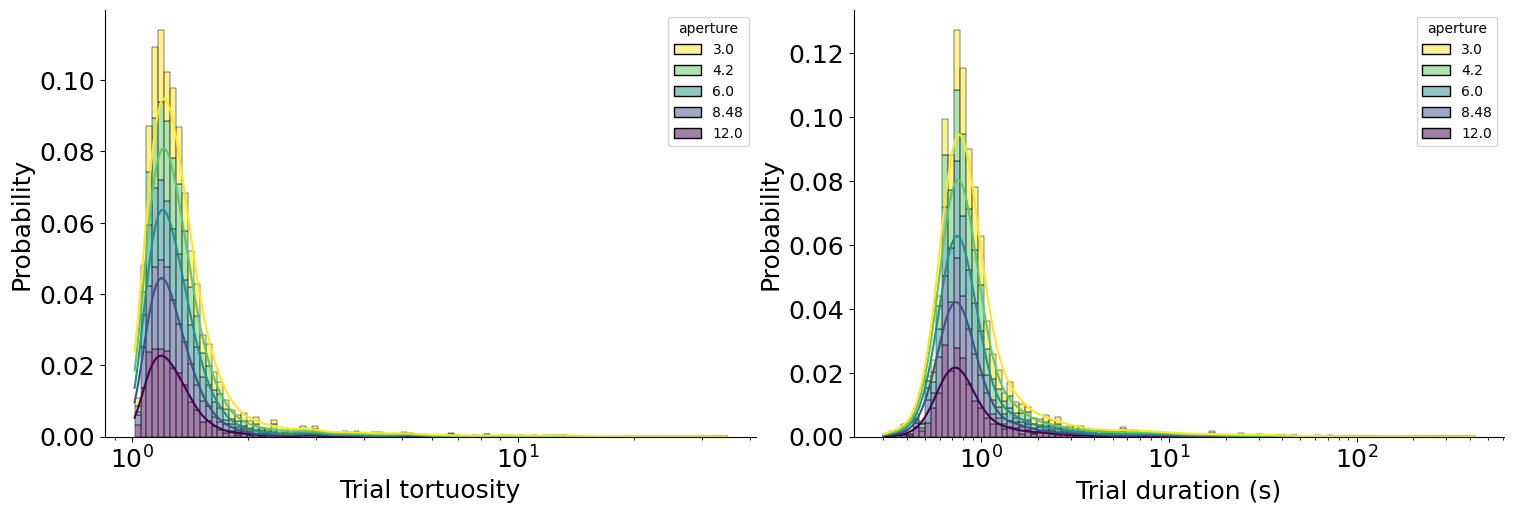

In [31]:
# Tortuosity and duration
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax = plotting.plot_tortuosity_duration_distribution(big_df, ax=ax, log_scale=True, cmap=plotting.colors_multi_aperture)
fig.tight_layout(pad=0.2)
ax[0].set_xlabel("Trial tortuosity")
ax[1].set_xlabel("Trial duration (s)")

In [32]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})
interpolated_j_shaped = utils.interpolate_j_shaped(big_df, box_df, n_points=500)

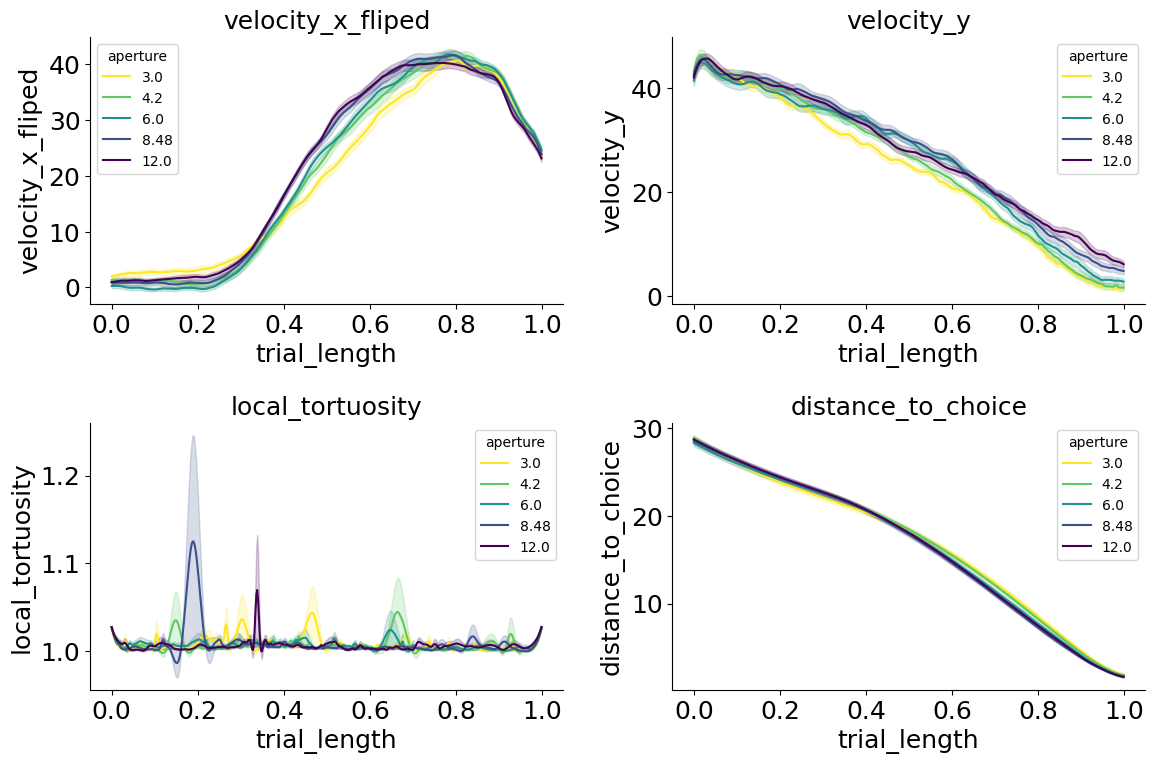

In [33]:
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for i, label in enumerate(
    ["velocity_x_fliped", "velocity_y", "local_tortuosity", "distance_to_choice"]
):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=(
            plotting.colors_aperture[:2]
            if len(mean_mouse.aperture.unique()) == 2
            else plotting.colors_multi_aperture
        ),
        hue="aperture",
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
plt.tight_layout(pad=2)

In [40]:
mean_mouse

,dataset,aperture,trial_left_choice,trial_length,time,heading_dir,head_angle,trial_tortuosity,trial_duration,x,...,distance_to_choice,optimal_p,local_tortuosity,trial,trial_step,head_angle_sin,head_angle_cos,heading_dir_sin,heading_dir_cos,velocity_x_fliped
0,Jacana_2024-08-20_1,3.0,0.0,0.000,1.070072e+06,-6.670739,4.658560,1.528020,1.247500,0.866157,...,27.946022,20.477623,1.027664,133.583333,0.0,0.080283,0.983589,-0.110446,0.928895,2.913550
1,Jacana_2024-08-20_1,3.0,0.0,0.002,1.070072e+06,-6.787882,4.823838,1.528020,1.247500,0.874369,...,27.844293,20.477623,1.022268,133.583333,1.0,0.083185,0.983918,-0.112304,0.929112,3.132400
2,Jacana_2024-08-20_1,3.0,0.0,0.004,1.070072e+06,-6.870593,4.953953,1.528020,1.247500,0.883177,...,27.746881,20.477623,1.017684,133.583333,2.0,0.085478,0.984184,-0.113626,0.929451,3.258193
3,Jacana_2024-08-20_1,3.0,0.0,0.006,1.070072e+06,-6.925996,5.049282,1.528020,1.247500,0.892469,...,27.652913,20.477623,1.013839,133.583333,3.0,0.087163,0.984394,-0.114524,0.929874,3.309237
4,Jacana_2024-08-20_1,3.0,0.0,0.008,1.070072e+06,-6.961214,5.110205,1.528020,1.247500,0.902134,...,27.561518,20.477623,1.010661,133.583333,4.0,0.088242,0.984533,-0.115106,0.930337,3.303837
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114995,Pheasant_2024-08-28_1,12.0,1.0,0.990,2.382865e+06,57.476986,4.757887,1.262235,0.740645,-16.913751,...,2.323212,11.578430,1.015306,123.580645,495.0,0.081667,0.983969,0.813919,0.518046,18.602301
114996,Pheasant_2024-08-28_1,12.0,1.0,0.992,2.382865e+06,57.568542,4.655347,1.262235,0.740645,-16.938130,...,2.296043,11.578430,1.017825,123.580645,496.0,0.079943,0.984433,0.814414,0.516592,18.295265
114997,Pheasant_2024-08-28_1,12.0,1.0,0.994,2.382865e+06,57.661491,4.550965,1.262235,0.740645,-16.962489,...,2.269200,11.578430,1.020704,123.580645,497.0,0.078185,0.984881,0.814864,0.515088,17.997130
114998,Pheasant_2024-08-28_1,12.0,1.0,0.996,2.382865e+06,57.755341,4.444296,1.262235,0.740645,-16.986982,...,2.242499,11.578430,1.023973,123.580645,498.0,0.076386,0.985293,0.815258,0.513541,17.718633


In [49]:
# get data
distance_to_choice_curves = pd.DataFrame(mean_mouse.groupby(["trial_length", "aperture"], as_index=False).distance_to_choice.mean())

In [50]:
distance_to_choice_curves

,trial_length,aperture,distance_to_choice
0,0.000,3.00,28.895167
1,0.000,4.20,28.843699
2,0.000,6.00,28.351712
3,0.000,8.48,28.576824
4,0.000,12.00,28.688126
...,...,...,...
2495,0.998,3.00,1.946980
2496,0.998,4.20,1.837806
2497,0.998,6.00,1.752375
2498,0.998,8.48,1.663474


aperture:3.0
Quadratic Term Coefficient: -15.910599200124503
p-value for Quadratic Term: 5.739679033024497e-230
aperture:4.2
Quadratic Term Coefficient: -15.720651544041406
p-value for Quadratic Term: 1.1708489952249457e-256
aperture:6.0
Quadratic Term Coefficient: -14.904815110620506
p-value for Quadratic Term: 9.294161849224548e-265
aperture:8.48
Quadratic Term Coefficient: -14.133430892410136
p-value for Quadratic Term: 9.327271981475026e-224
aperture:12.0
Quadratic Term Coefficient: -14.429975712348634
p-value for Quadratic Term: 3.905378733941523e-241


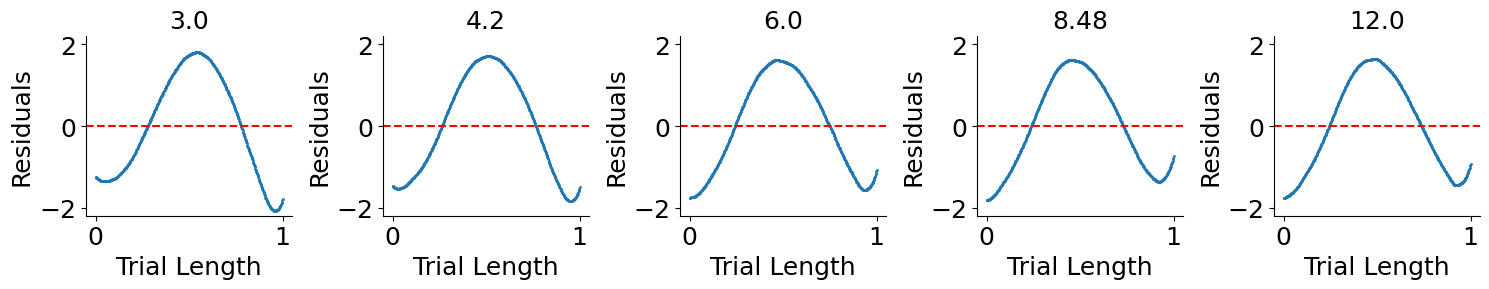

In [68]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

quad_coefs = []
group_labels = []
fig, ax = plt.subplots(1, len(distance_to_choice_curves.aperture.unique()), figsize=(15, 3))
for j, i in enumerate(distance_to_choice_curves.aperture.unique()):
    print(f'aperture:{i}')
    X = np.linspace(0, 1, 500)
    Y = distance_to_choice_curves[distance_to_choice_curves.aperture == i].distance_to_choice.values

    X_reshaped = X.reshape(-1, 1)
    model = LinearRegression().fit(X_reshaped, Y)
    Y_pred = model.predict(X_reshaped)

    residuals = Y - Y_pred

    X_poly = np.column_stack((X, X**2))  # Quadratic model
    X_poly = sm.add_constant(X_poly)  # Add intercept
    model_poly = sm.OLS(Y, X_poly).fit()

    quad_coef = model_poly.params[2]  # Coefficient of X^2
    quad_p_value = model_poly.pvalues[2]

    print(f"Quadratic Term Coefficient: {quad_coef}")
    print(f"p-value for Quadratic Term: {quad_p_value}")

    quad_coefs.append(quad_coef)
    group_labels.append(str(i))
    
    # Plot Residuals
    ax[j].scatter(X, residuals, s=1, label="Residuals")
    ax[j].axhline(0, color="r", linestyle="--")
    ax[j].set_xlabel("Trial Length")
    ax[j].set_ylabel("Residuals")
    ax[j].set_title(f"{i}")
    ax[j].set_ylim(-2.2, 2.2)

plt.tight_layout()
plt.show()


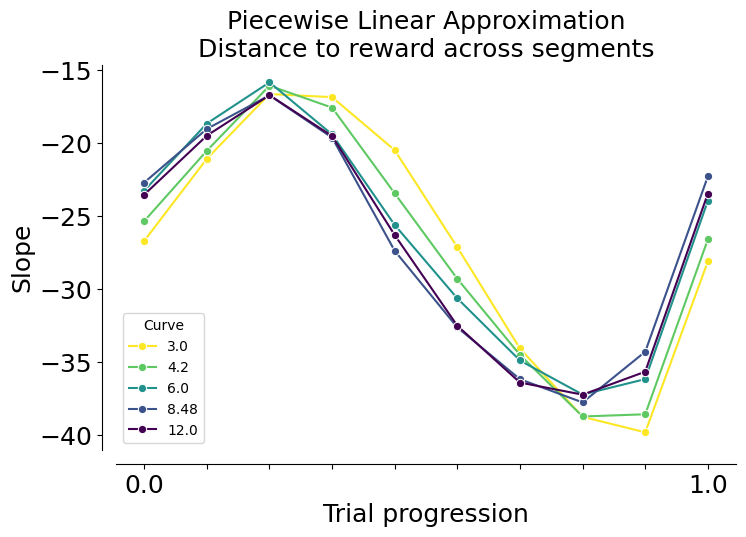

In [100]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

X = np.linspace(0, 1, 500)
num_segments = 10
segment_length = 500 // num_segments

slope_data = []
for j, aperture in enumerate(distance_to_choice_curves.aperture.unique()):
    Y = distance_to_choice_curves[distance_to_choice_curves.aperture == aperture].distance_to_choice.values

    slopes = []
    for i in range(num_segments):
        start = i * segment_length
        end = start + segment_length
        X_segment = X[start:end].reshape(-1, 1)
        Y_segment = Y[start:end]

        model = LinearRegression().fit(X_segment, Y_segment)
        slope = model.coef_[0]  # Extract slope (β1)
        slopes.append(slope)

    # Store slopes for comparison
    slope_data.append(pd.DataFrame({"Slope": slopes, "Segment": np.arange(num_segments), "Curve": [aperture] * num_segments}))

# Combine all data
df_slopes = pd.concat(slope_data)

# Plot the slopes for each segment
plt.figure(figsize=(8, 5))
sns.lineplot(data=df_slopes, x="Segment", y="Slope", hue="Curve", marker="o", palette=plotting.colors_multi_aperture)
plt.xlabel("Trial progression")
plt.ylabel("Slope")
plt.xticks(np.arange(num_segments), [0.0, "", "", "", "", "", "", "", "", 1.0])
plt.title("Piecewise Linear Approximation\nDistance to reward across segments")
sns.despine(offset=10)
plt.show()



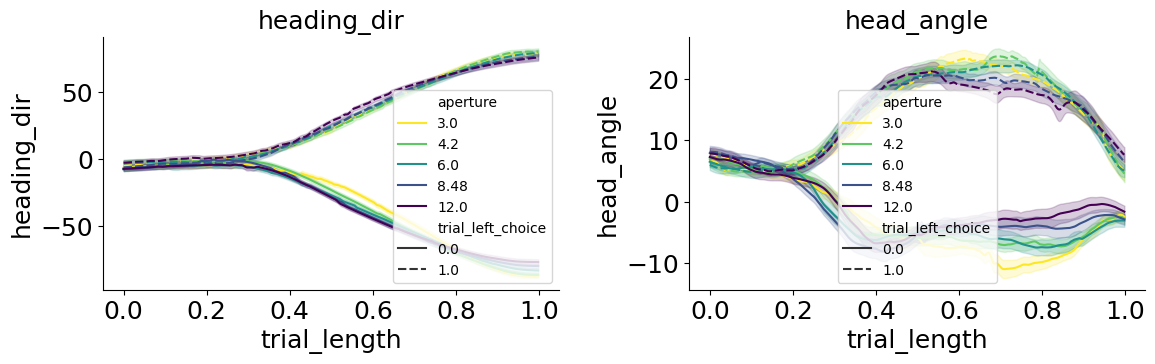

In [35]:
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

for i, label in enumerate(["heading_dir", "head_angle"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else plotting.colors_multi_aperture,
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
    
        
plt.tight_layout(pad=2)

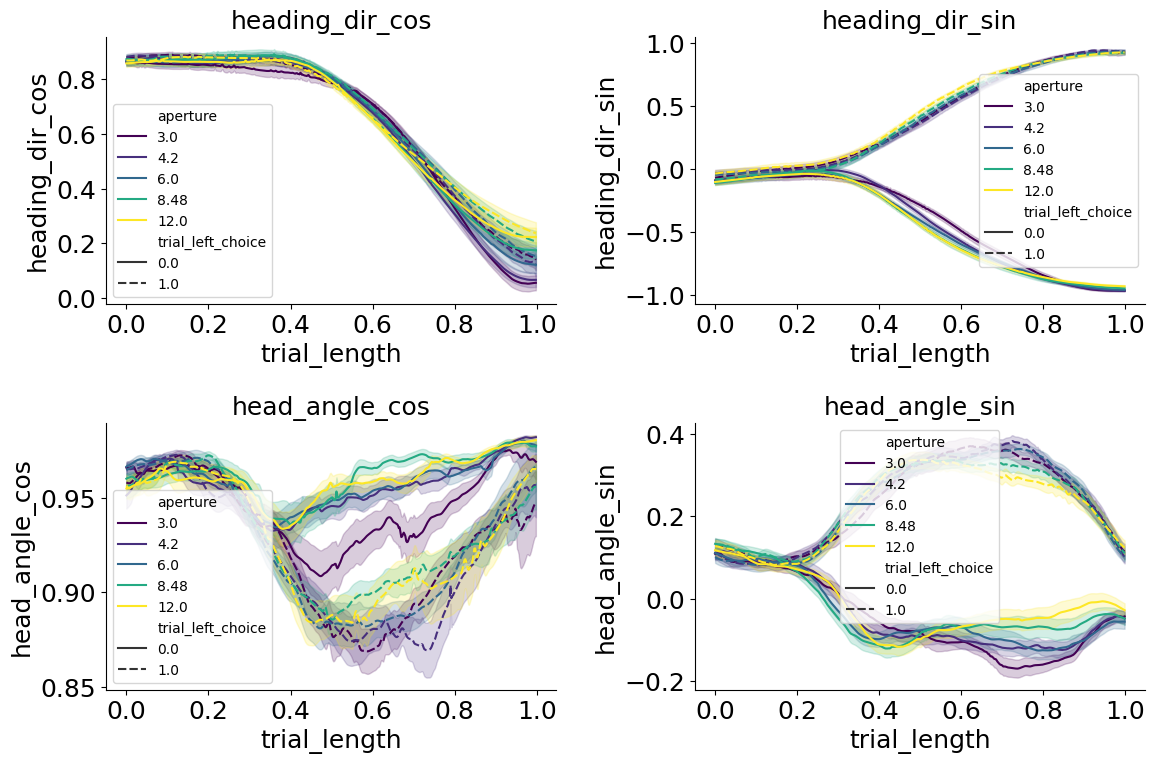

In [36]:
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

for i, label in enumerate(["heading_dir_cos",  "heading_dir_sin", "head_angle_cos", "head_angle_sin"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice if len(mean_mouse.aperture.unique()) == 2 else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_title(f"{label}")
    
        
plt.tight_layout(pad=2)